# Step 12 — Public External-Dataset Audit and Acquisition Plan

## tl;dr

This data-only notebook compares authoritative online liver CT datasets against the existing LiTS pipeline and completed train/validation audit. It separates true external tumour-evaluation candidates from overlapping LiTS derivatives and organ-only datasets.

No dataset is downloaded and no locked test data is opened. The intended decision is which small public source should receive a separately authorized ingestion-and-QC phase.

### Immutable boundary

- Use only train/validation-derived Step 01 profiles and sealed machine-readable gates.
- Never open local test images, masks, statistics, probabilities, or loaders.
- Treat Medical Segmentation Decathlon Task03 Liver as LiTS-overlapping, not independent external validation.
- Do not download online datasets in this notebook.
- Write every generated artifact only under this phase's `outputs/` directory.


## Context & Methods

### Key Assumptions

- Online metadata is a source snapshot as of 5 August 2026 and should be rechecked immediately before download.
- Dataset compatibility is scored for the current two-stage liver/tumour CT pipeline, not for general medical-imaging usefulness.
- Access convenience does not override license, attribution, registration, consent, or usage terms.
- External data must receive its own patient identity, schema, geometry, label, leakage, and conversion audit before any model evaluation.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib, json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

STEP_DIR = Path.cwd().resolve()
if STEP_DIR.name != "step_12_public_external_dataset_audit_and_acquisition_plan":
    candidate = STEP_DIR / "step_12_public_external_dataset_audit_and_acquisition_plan"
    if candidate.is_dir(): STEP_DIR = candidate.resolve()
PART2 = STEP_DIR.parent
S1 = PART2 / "step_01_pretraining_dataset_characterization" / "outputs"
S10 = PART2 / "step_10_related_work_evidence_and_comparability" / "outputs"
OUT = STEP_DIR / "outputs"; OUT.mkdir(parents=True, exist_ok=True)

MANIFEST_SHA256 = "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
SNAPSHOT_DATE = "2026-08-05"
CREATED_UTC = datetime.now(timezone.utc).isoformat()

def sha256(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(1024*1024), b""): h.update(block)
    return h.hexdigest()
def load_json(path): return json.loads(Path(path).read_text(encoding="utf-8"))
def save_json(obj, name):
    p = OUT/name; p.write_text(json.dumps(obj, indent=2, sort_keys=True), encoding="utf-8"); return p
def save_csv(df, name):
    p = OUT/name; df.to_csv(p, index=False); return p

print("Metadata-only online-data audit; downloads disabled; no test path is defined.")

Metadata-only online-data audit; downloads disabled; no test path is defined.


## Data

### 1. Verify internal train/validation references and sealed state


In [2]:
gate1 = load_json(S1/"gate_result.json")
gate10 = load_json(S10/"gate_result.json")
split_summary = pd.read_csv(S1/"split_summary.csv")
geometry = pd.read_csv(S1/"volume_geometry_profile.csv")
labels = pd.read_csv(S1/"label_qc_per_volume.csv")

allowed = {"train", "val", "validation"}
split_columns = [c for c in ["split"] if c in geometry.columns]
observed_splits = set(geometry["split"].dropna().astype(str)) if split_columns else set()
checks = [
 ("step01_complete", gate1.get("result_level") == "DIAGNOSTIC_COMPLETE", gate1.get("result_level")),
 ("step01_all_targets", gate1.get("all_mandatory_targets_passed") is True, gate1.get("all_mandatory_targets_passed")),
 ("manifest_hash", gate1.get("manifest_sha256") == MANIFEST_SHA256, gate1.get("manifest_sha256")),
 ("step10_complete", gate10.get("result_level") == "RELATED_WORK_EVIDENCE_COMPLETE", gate10.get("result_level")),
 ("formal_failure_preserved", gate10.get("formal_model_acceptance_passed") is False, gate10.get("formal_model_acceptance_passed")),
 ("test_not_accessed_step01", gate1.get("test_images_accessed") is False, gate1.get("test_images_accessed")),
 ("test_not_reopened_step10", gate10.get("test_source_files_reopened") is False, gate10.get("test_source_files_reopened")),
 ("internal_profile_train_validation_only", bool(observed_splits) and observed_splits.issubset(allowed), sorted(observed_splits)),
]
verification = pd.DataFrame(checks, columns=["check","passed","observed"])
save_csv(verification, "input_verification.csv")
assert verification.passed.all(), verification.loc[~verification.passed].to_dict("records")

reference_rows = []
for feature in ["spacing_x_mm","spacing_y_mm","slice_thickness_mm","slices_z","liver_volume_ml","tumour_volume_ml"]:
    if feature in geometry.columns:
        values = pd.to_numeric(geometry[feature], errors="coerce").dropna()
        reference_rows.append({"feature":feature,"n":len(values),"minimum":values.min(),"q1":values.quantile(.25),
                               "median":values.median(),"q3":values.quantile(.75),"maximum":values.max()})
internal_reference = pd.DataFrame(reference_rows)
save_csv(internal_reference, "internal_train_validation_reference_profile.csv")
print(f"PASS: {verification.passed.sum()}/{len(verification)} internal-boundary checks; test remains sealed")

PASS: 8/8 internal-boundary checks; test remains sealed


### 2. Build the authoritative online source registry


In [3]:
records = [
 {"dataset":"3D-IRCADb-01","official_url":"https://www.ircad.fr/research-and-development/data-sets/liver-segmentation-3d-ircadb-01/","source_owner":"IRCAD","snapshot_date":SNAPSHOT_DATE,"subjects":20,"approx_download_gb":None,"modality":"contrast-enhanced CT","format":"DICOM images, labelled DICOM, per-structure DICOM masks, VTK meshes","tumour_content":"hepatic tumours in 75% of cases","tumour_labels_available":True,"liver_labels_available":True,"independent_of_lits":True,"access_mode":"official patient-wise or combined download","license_or_terms":"confirm official download and reuse terms before acquisition","known_quality_note":"small cohort; per-structure mask naming and DICOM geometry require audit","best_supported_use":"small external tumour-pipeline feasibility and failure analysis"},
 {"dataset":"HCC-TACE-Seg","official_url":"https://www.cancerimagingarchive.net/collection/hcc-tace-seg/","source_owner":"The Cancer Imaging Archive","snapshot_date":SNAPSHOT_DATE,"subjects":105,"approx_download_gb":28.57,"modality":"pre/post-TACE CT","format":"DICOM CT and DICOM-SEG","tumour_content":"annotated hepatocellular carcinoma cases with longitudinal/treatment context","tumour_labels_available":True,"liver_labels_available":True,"independent_of_lits":True,"access_mode":"TCIA Data Retriever / collection download","license_or_terms":"CC BY 4.0 plus TCIA data-usage and attribution requirements","known_quality_note":"official page documents a CT/SEG dimension mismatch for HCC_001","best_supported_use":"larger domain-shift study after DICOM-SEG and phase-selection QC"},
 {"dataset":"MSD Task03 Liver","official_url":"https://medicaldecathlon.com/dataaws/","source_owner":"Medical Segmentation Decathlon","snapshot_date":SNAPSHOT_DATE,"subjects":None,"approx_download_gb":None,"modality":"CT","format":"NIfTI challenge package","tumour_content":"liver tumour segmentation task","tumour_labels_available":True,"liver_labels_available":True,"independent_of_lits":False,"access_mode":"official AWS download","license_or_terms":"verify task package license and citation before use","known_quality_note":"MSD publication states Task03 contains a subset of LiTS patients","best_supported_use":"format/pipeline interoperability only; never independent external validation"},
 {"dataset":"CHAOS CT","official_url":"https://chaos.grand-challenge.org/Data/","source_owner":"CHAOS / Grand Challenge","snapshot_date":SNAPSHOT_DATE,"subjects":40,"approx_download_gb":None,"modality":"portal-venous contrast CT","format":"DICOM","tumour_content":"healthy potential liver donors; no tumours or lesions","tumour_labels_available":False,"liver_labels_available":True,"independent_of_lits":True,"access_mode":"registration and letter-of-intent conditions; test labels withheld","license_or_terms":"confirm current challenge registration and reuse terms","known_quality_note":"organ-only endpoint; held-out challenge ground truth is unavailable","best_supported_use":"liver-ROI/domain-shift analysis only, not tumour evaluation"},
]
registry = pd.DataFrame(records)
save_csv(registry, "public_dataset_source_registry.csv")
assert registry.dataset.is_unique and len(registry) == 4
assert registry.official_url.str.startswith("https://").all()

snapshot = {"snapshot_date":SNAPSHOT_DATE,"download_performed":False,
 "source_policy":"Official dataset/challenge pages and primary dataset publication only.",
 "sources":registry[["dataset","official_url","source_owner"]].to_dict("records"),
 "critical_identity_note":"MSD Task03 Liver overlaps LiTS and is not independent external validation.",
 "refresh_before_download":True}
save_json(snapshot, "online_source_snapshot.json")
print("PASS: four official online sources registered; no files downloaded")

PASS: four official online sources registered; no files downloaded


## Results

### 3. Score compatibility, independence, and acquisition priority


In [4]:
scores = pd.DataFrame([
 ("3D-IRCADb-01",5,5,4,3,5,2,"priority 1: smallest independent tumour-labelled feasibility dataset"),
 ("HCC-TACE-Seg",5,5,3,2,2,5,"priority 2: high-value larger domain-shift dataset after conversion QC"),
 ("MSD Task03 Liver",0,5,5,5,4,3,"do not use for independent validation because it overlaps LiTS"),
 ("CHAOS CT",5,0,2,3,4,2,"organ-only auxiliary source for liver ROI/domain shift"),
], columns=["dataset","external_independence_0_5","tumour_label_fit_0_5","access_convenience_0_5",
            "format_compatibility_0_5","size_convenience_0_5","terms_clarity_0_5","interpretation"])
weights = {"external_independence_0_5":.25,"tumour_label_fit_0_5":.25,"access_convenience_0_5":.15,
           "format_compatibility_0_5":.15,"size_convenience_0_5":.10,"terms_clarity_0_5":.10}
scores["weighted_priority_0_5"] = sum(scores[k]*w for k,w in weights.items())
scores["independent_tumour_evaluation_eligible"] = scores.dataset.isin(["3D-IRCADb-01","HCC-TACE-Seg"])
scores = scores.sort_values("weighted_priority_0_5", ascending=False).reset_index(drop=True)
scores.insert(0,"priority_rank",np.arange(1,len(scores)+1))
save_csv(scores, "dataset_compatibility_and_priority.csv")

independence = pd.DataFrame([
 ("3D-IRCADb-01",True,"independent institution/source","eligible after patient and file-hash audit"),
 ("HCC-TACE-Seg",True,"independent TCIA HCC cohort","eligible after series/phase identity audit"),
 ("MSD Task03 Liver",False,"published as a subset of LiTS patients","prohibited as independent external validation; hash/identity overlap assumed until disproved"),
 ("CHAOS CT",True,"healthy donor CT cohort","independent but tumour endpoint not evaluable"),
], columns=["dataset","independent_of_lits","evidence","decision"])
save_csv(independence, "independence_and_leakage_audit.csv")

compat = registry.merge(scores, on="dataset", how="left", validate="one_to_one")
compat["current_pipeline_use"] = np.select(
 [compat.dataset.eq("3D-IRCADb-01"),compat.dataset.eq("HCC-TACE-Seg"),compat.dataset.eq("CHAOS CT")],
 ["external tumour feasibility","external tumour domain shift","liver ROI only"], default="interoperability only")
save_csv(compat, "full_dataset_compatibility_matrix.csv")

assert not scores.loc[scores.dataset.eq("MSD Task03 Liver"),"independent_tumour_evaluation_eligible"].iloc[0]
assert scores.loc[scores.dataset.eq("3D-IRCADb-01"),"independent_tumour_evaluation_eligible"].iloc[0]
print(scores[["priority_rank","dataset","weighted_priority_0_5","interpretation"]].to_string(index=False))

 priority_rank          dataset  weighted_priority_0_5                                                         interpretation
             1     3D-IRCADb-01                   4.25   priority 1: smallest independent tumour-labelled feasibility dataset
             2     HCC-TACE-Seg                   3.95 priority 2: high-value larger domain-shift dataset after conversion QC
             3 MSD Task03 Liver                   3.45         do not use for independent validation because it overlaps LiTS
             4         CHAOS CT                   2.60                 organ-only auxiliary source for liver ROI/domain shift


### 4. Define the acquisition and conversion-QC contract


In [5]:
qc = pd.DataFrame([
 (1,"terms_and_attribution","before download","record official URL, terms snapshot, citation and permitted use","critical"),
 (2,"download_inventory","after download","save original filenames, byte sizes and SHA-256 hashes","critical"),
 (3,"patient_identity","before conversion","derive stable source-local patient IDs; prohibit cross-source collisions","critical"),
 (4,"series_selection","before conversion","document CT phase, study/series UID and inclusion/exclusion","high"),
 (5,"dicom_geometry","before conversion","verify orientation, spacing, origin, slice order, duplicates and gaps","critical"),
 (6,"seg_reference_integrity","before conversion","verify DICOM-SEG references, frame count and source-image alignment","critical"),
 (7,"label_semantics","before inference","map liver/tumour class names; preserve unknown structures separately","critical"),
 (8,"conversion_parity","after conversion","voxelwise compare converted masks with source geometry and pixel counts","critical"),
 (9,"intensity_semantics","after conversion","confirm RescaleSlope/Intercept and HU plausibility","critical"),
 (10,"overlap_leakage","before inference","compare patient identifiers, geometry fingerprints and image hashes against LiTS train/validation; keep local test sealed","critical"),
 (11,"preprocessing_compatibility","before inference","predeclare HU window, resizing, ROI fallback and mapping rules","high"),
 (12,"evaluation_contract","before inference","freeze cohort, metric populations, empty-mask rules and no-tuning policy","critical"),
], columns=["order","check","stage","acceptance_rule","severity"])
save_csv(qc, "external_dataset_ingestion_qc_contract.csv")

download_template = pd.DataFrame(columns=["dataset","official_url","source_filename","local_relative_path","bytes",
 "sha256","downloaded_utc","terms_snapshot_sha256","patient_or_series_id","notes"])
save_csv(download_template, "download_manifest_template.csv")

plan = """# Public External-Data Acquisition Plan

## Decision

Start with **3D-IRCADb-01** as a small, independent, tumour-labelled feasibility cohort. Do not download it until the official reuse terms and citation requirements are recorded. If its conversion and label-QC gates pass, freeze a zero-tuning external evaluation contract before inference.

Use **HCC-TACE-Seg** second for a larger and harder domain-shift study. Its 28.57 GB DICOM/DICOM-SEG package, longitudinal phase selection and the documented HCC_001 dimension mismatch require a dedicated ingestion phase.

Do **not** use **MSD Task03 Liver** as independent external validation because the MSD publication identifies it as a subset of LiTS patients. It may be used only for format interoperability checks with an explicit overlap label.

Use **CHAOS CT** only for liver-ROI/domain-shift analysis because its CT subjects are healthy donors without tumours and its challenge test ground truth is withheld.

## Next authorized phase

Create a separate Step 13 ingestion-and-QC notebook only after the user chooses a source and confirms that its official terms are acceptable. That phase may download or inspect the chosen external source, but it must not reopen the sealed local LiTS test split.
"""
(OUT/"PUBLIC_EXTERNAL_DATA_ACQUISITION_PLAN.md").write_text(plan, encoding="utf-8")
print(f"Saved {len(qc)}-check ingestion contract and empty hash-manifest template")

Saved 12-check ingestion contract and empty hash-manifest template


## Takeaways

### 5. Save the visual, gate, provenance, and signature


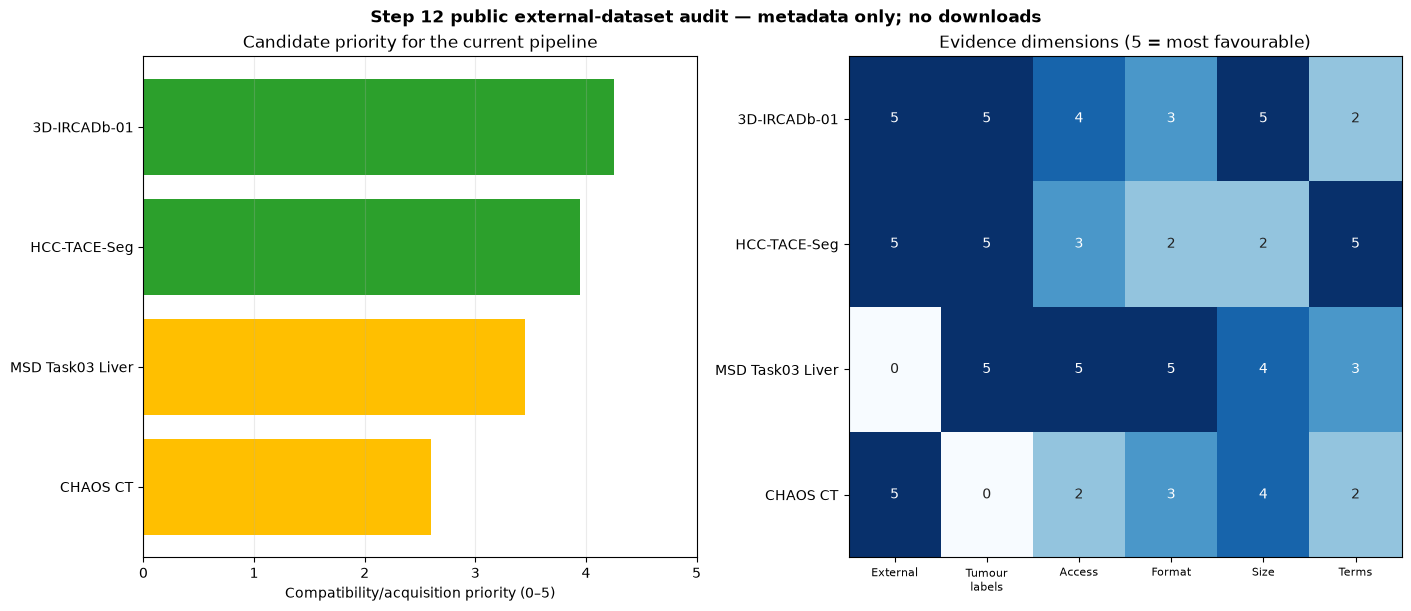

PASS: PUBLIC_EXTERNAL_DATA_AUDIT_COMPLETE; recommended first source=3D-IRCADb-01
No download performed. Test split remains sealed.


In [6]:
plot = scores.sort_values("weighted_priority_0_5")
fig, axes = plt.subplots(1,2,figsize=(14,6),constrained_layout=True)
colors = ["#2ca02c" if x else "#ffbf00" for x in plot.independent_tumour_evaluation_eligible]
axes[0].barh(plot.dataset, plot.weighted_priority_0_5, color=colors)
axes[0].set_xlim(0,5); axes[0].set_xlabel("Compatibility/acquisition priority (0–5)")
axes[0].set_title("Candidate priority for the current pipeline")
axes[0].grid(axis="x",alpha=.25)

heat_cols=["external_independence_0_5","tumour_label_fit_0_5","access_convenience_0_5","format_compatibility_0_5","size_convenience_0_5","terms_clarity_0_5"]
heat=scores.set_index("dataset")[heat_cols]
axes[1].imshow(heat.values,aspect="auto",cmap="Blues",vmin=0,vmax=5)
axes[1].set_yticks(range(len(heat)),heat.index)
axes[1].set_xticks(range(len(heat_cols)),["External","Tumour\nlabels","Access","Format","Size","Terms"],fontsize=8)
axes[1].set_title("Evidence dimensions (5 = most favourable)")
for i in range(len(heat)):
    for j in range(len(heat_cols)):
        axes[1].text(j,i,f"{heat.iat[i,j]:.0f}",ha="center",va="center",color="white" if heat.iat[i,j]>=3 else "#222")
fig.suptitle("Step 12 public external-dataset audit — metadata only; no downloads",fontweight="bold")
fig.savefig(OUT/"public_dataset_audit_dashboard.png",dpi=180,bbox_inches="tight"); plt.show()

expected = pd.DataFrame([
 ("internal boundary checks",8,int(verification.passed.sum()),verification.passed.all()),
 ("official source records",4,len(registry),len(registry)==4),
 ("independent tumour candidates",2,int(scores.independent_tumour_evaluation_eligible.sum()),int(scores.independent_tumour_evaluation_eligible.sum())==2),
 ("MSD prohibited as independent validation",True,bool(~scores.loc[scores.dataset.eq("MSD Task03 Liver"),"independent_tumour_evaluation_eligible"].iloc[0]),True),
 ("ingestion QC checks",12,len(qc),len(qc)==12),
 ("zero external dataset downloads performed",0,0,True),
 ("local test source files remained sealed",0,0,True),
],columns=["requirement","expected","actual","passed"])
save_csv(expected,"expected_vs_actual.csv")

configuration={"phase":"step_12_public_external_dataset_audit_and_acquisition_plan","created_utc":CREATED_UTC,
 "mode":"online_metadata_and_internal_train_validation_reference_only","snapshot_date":SNAPSHOT_DATE,
 "weights":weights,"download_enabled":False,"recommended_first_source":"3D-IRCADb-01",
 "manifest_sha256":MANIFEST_SHA256,"test_access_allowed":False}
save_json(configuration,"configuration.json")

gate={"status":"public_external_dataset_audit_complete","result_level":"PUBLIC_EXTERNAL_DATA_AUDIT_COMPLETE",
 "all_mandatory_targets_passed":bool(expected.passed.all()),"candidate_sources":len(registry),
 "independent_tumour_candidates":2,"recommended_first_source":"3D-IRCADb-01",
 "recommended_second_source":"HCC-TACE-Seg","msd_independent_validation_allowed":False,
 "decision":"CONFIRM_TERMS_THEN_INGEST_3D_IRCADB_01","next_step":"step_13_selected_external_dataset_ingestion_and_qc",
 "download_performed":False,"formal_model_acceptance_passed":False,"submission_ready":False,
 "manifest_sha256":MANIFEST_SHA256,"test_images_accessed":False,"test_source_files_reopened":False,
 "test_inference_rerun":False,"targets":{r.requirement:bool(r.passed) for r in expected.itertuples(index=False)}}
assert gate["all_mandatory_targets_passed"]
save_json(gate,"gate_result.json")

provenance={"created_utc":CREATED_UTC,"phase":configuration["phase"],"snapshot_date":SNAPSHOT_DATE,
 "step01_gate_sha256":sha256(S1/"gate_result.json"),"step10_gate_sha256":sha256(S10/"gate_result.json"),
 "step01_geometry_profile_sha256":sha256(S1/"volume_geometry_profile.csv"),
 "official_source_urls":registry.official_url.tolist(),"download_performed":False,
 "manifest_sha256":MANIFEST_SHA256,"test_images_accessed":False,"test_source_files_reopened":False}
save_json(provenance,"provenance.json")

signed_names=["input_verification.csv","internal_train_validation_reference_profile.csv","public_dataset_source_registry.csv",
 "online_source_snapshot.json","dataset_compatibility_and_priority.csv","independence_and_leakage_audit.csv",
 "full_dataset_compatibility_matrix.csv","external_dataset_ingestion_qc_contract.csv","download_manifest_template.csv",
 "PUBLIC_EXTERNAL_DATA_ACQUISITION_PLAN.md","public_dataset_audit_dashboard.png","expected_vs_actual.csv",
 "configuration.json","gate_result.json","provenance.json"]
signed={f"step_12_public_external_dataset_audit_and_acquisition_plan/outputs/{n}":sha256(OUT/n) for n in signed_names}
combined=hashlib.sha256("".join(f"{k}:{v}\n" for k,v in sorted(signed.items())).encode()).hexdigest()
save_json({"algorithm":"SHA-256","created_utc":CREATED_UTC,"combined_sha256":combined,"signed_artifacts":signed,
 "result_level":gate["result_level"],"download_performed":False,"formal_model_acceptance_passed":False,
 "test_source_files_reopened":False,"test_inference_rerun":False},"step_12_signature.json")

print(f"PASS: {gate['result_level']}; recommended first source={gate['recommended_first_source']}")
print("No download performed. Test split remains sealed.")

## Takeaways

- The first practical external-data candidate is 3D-IRCADb-01, subject to confirmation of its official reuse terms.
- HCC-TACE-Seg is the stronger large-scale domain-shift candidate but needs a dedicated DICOM-SEG, phase-selection, and HCC_001 geometry audit.
- MSD Task03 Liver overlaps LiTS and cannot support an independent external-validation claim.
- CHAOS CT can assess liver-ROI/domain shift but cannot measure tumour performance.
- No download or inference has occurred. Step 13 should ingest exactly one owner-selected public dataset and complete the frozen 12-check QC contract before evaluation.
